### Imports

In [1]:
import warnings

import torch

from src.config import CONFIG
from src.engine import train_kfold, load_and_benchmark
from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.types.model_type import ModelType
from src.utils.hyperparameter_sweep_utils import run_hyperparameter_sweep
from src.utils.plotting_utils import plot_training_history

warnings.filterwarnings('ignore', category=UserWarning)

/Users/jackrong/Developer/bio-inspired-sonar-for-underwater-object-detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODEL = ModelType.CNN
DATASET = DatasetType.SHIPSEAR
FILTERBANK = FilterbankType.MEL

### Device

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [4]:
if CONFIG.hyperparameter_tuning.should_run:
    run_hyperparameter_sweep(device, MODEL, DATASET, FILTERBANK)

### Training

Loading 2223 spectrograms...
Finished loading spectrograms.
Time taken: 1 seconds

Fold 1/5

Model Config: {'in_channels': 1, 'num_classes': 5, 'channels': [16, 32]}
Hyperparameters used: {'lr': 0.0009330999787374547, 'weight_decay': 0.0003365298271997014, 'model_init': {'dropout': 0.2479994147624657}}

Training CNN...
[Epoch 1/100]
[Train] Loss: 1.48 | Acc: 29.38% | Macro-F1: 0.2783 | Weighted-F1: 0.2748
[Val] Loss: 1.24 | Acc: 42.13% | Macro-F1: 0.4263 | Weighted-F1: 0.3862
Epoch Duration: 13s | Total Time Elapsed: 13s

[Epoch 2/100]
[Train] Loss: 1.20 | Acc: 40.38% | Macro-F1: 0.4014 | Weighted-F1: 0.3880
[Val] Loss: 1.11 | Acc: 40.45% | Macro-F1: 0.3982 | Weighted-F1: 0.3282
Epoch Duration: 1s | Total Time Elapsed: 13s

[Epoch 3/100]
[Train] Loss: 1.00 | Acc: 50.25% | Macro-F1: 0.5153 | Weighted-F1: 0.4960
[Val] Loss: 0.98 | Acc: 57.30% | Macro-F1: 0.5537 | Weighted-F1: 0.5620
Epoch Duration: 1s | Total Time Elapsed: 14s

[Epoch 4/100]
[Train] Loss: 0.90 | Acc: 59.25% | Macro-F1: 0

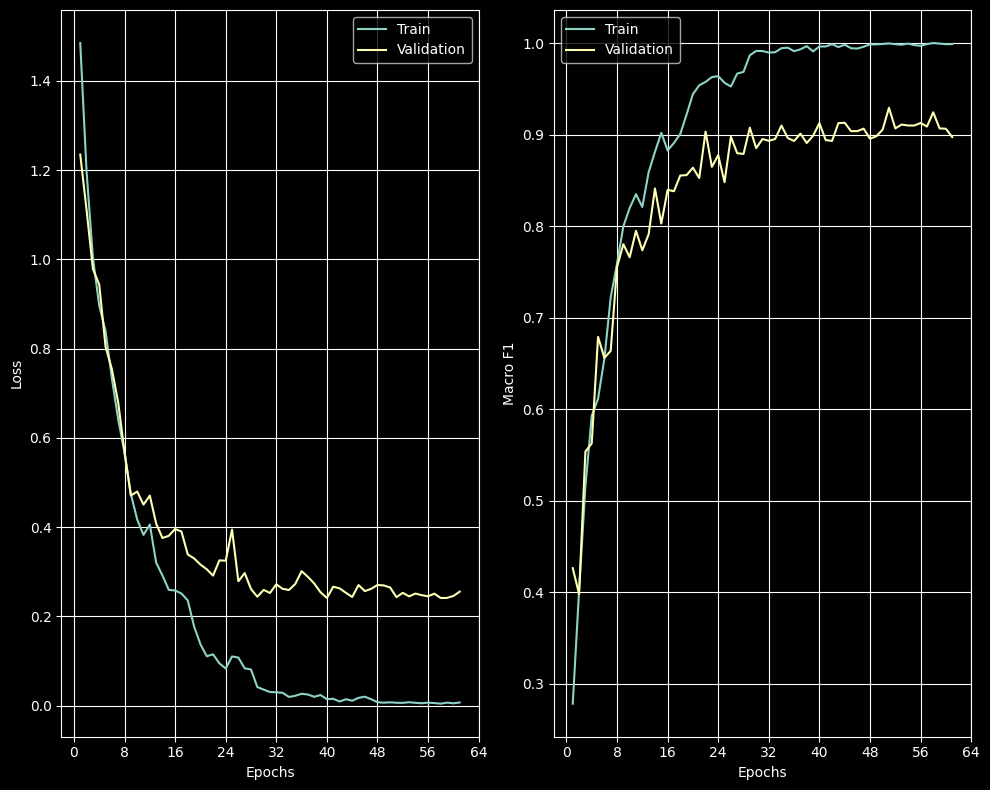

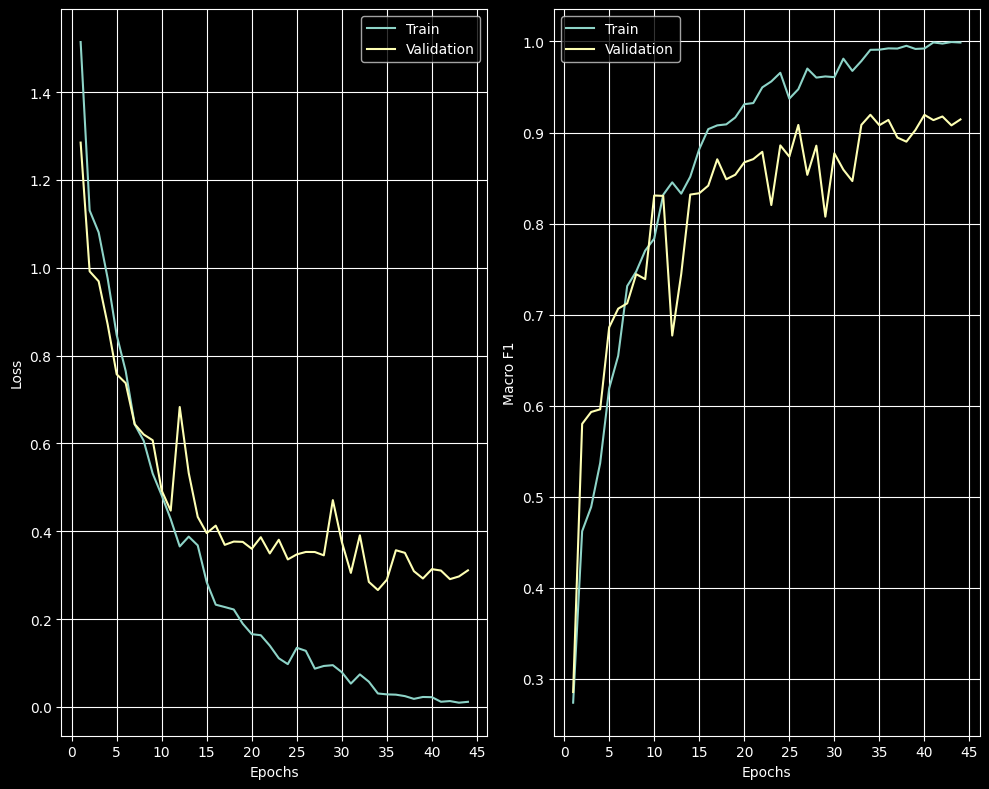

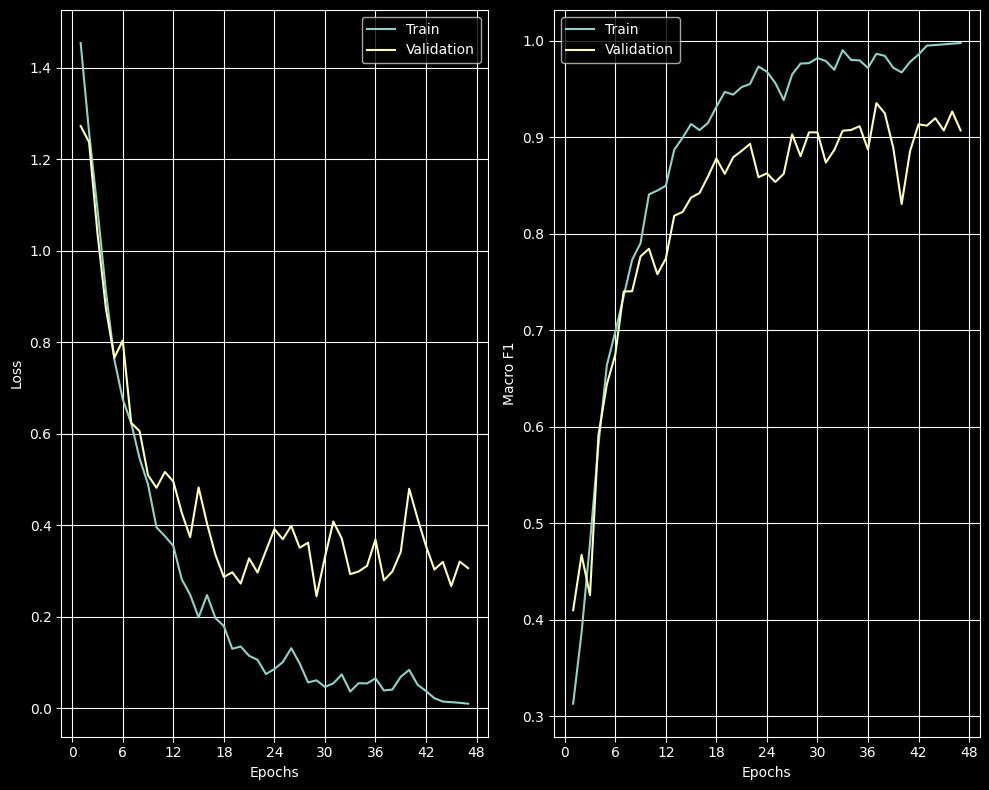

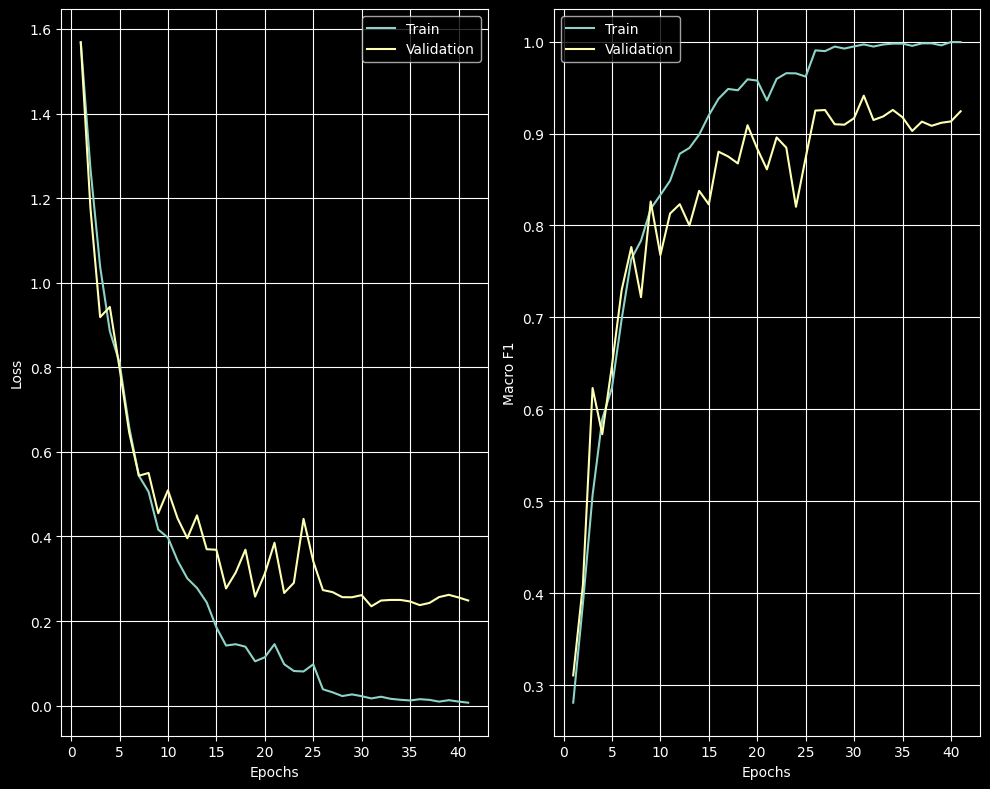

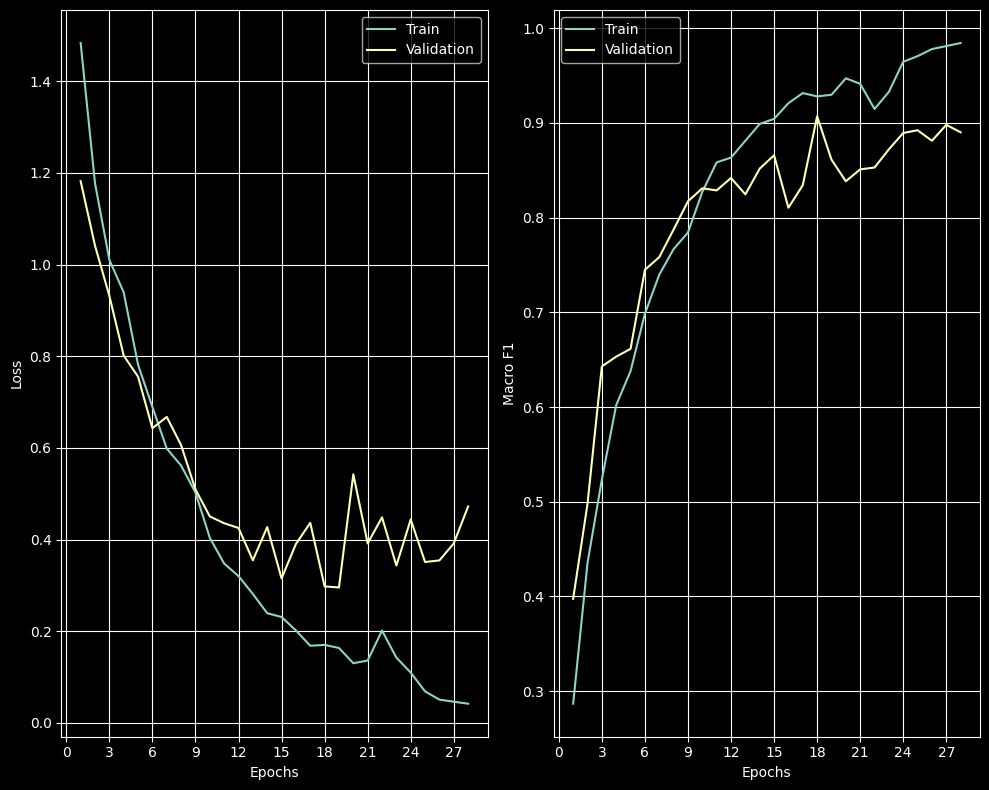

In [5]:
results = train_kfold(device, MODEL, DATASET, FILTERBANK)
for i, fold in enumerate(results['folds']):
    plot_training_history(**fold['epoch_history'])

### Benchmark

In [ ]:
load_and_benchmark(device, MODEL, DATASET, FILTERBANK)